# **Prediksi Harga Mobil menggunakan Deep Learning (ANN)**

Notebook ini berisi model deep learning berbasis **Artificial Neural Network (ANN)** untuk memprediksi harga mobil menggunakan Automobile Dataset.  

**Arsitektur yang digunakan:**
- **Deeper ANN with Dropout (3 Hidden Layers + Regularization)

**Metrik Evaluasi:** RMSE · MAE · MAPE · R²

**Skor yang didapat:**
RMSE: 6,366

*   RMSE: 6,366
*   MAE: 3,968
*   MAPE: 19.96%
*   R²: 0.6687



---
Dataset: https://www.kaggle.com/datasets/toramky/automobile-dataset

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)



## 2. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Celerates/Assignments/Asynchronus 5/Automobile_data.csv"

df = pd.read_csv(file_path)
print(f"Shape dataset : {df.shape}")
print(f"Kolom         : {df.columns.tolist()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape dataset : (205, 26)
Kolom         : ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
df.describe().round(2)

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00
mean,0.83,98.76,174.05,65.91,53.72,2555.57,126.91,10.14,25.22,30.75
std,1.25,6.02,12.34,2.15,2.44,520.68,41.64,3.97,6.54,6.89
min,-2.00,86.60,141.10,60.30,47.80,1488.00,61.00,7.00,13.00,16.00
25%,0.00,94.50,166.30,64.10,52.00,2145.00,97.00,8.60,19.00,25.00
50%,1.00,97.00,173.20,65.50,54.10,2414.00,120.00,9.00,24.00,30.00
75%,2.00,102.40,183.10,66.90,55.50,2935.00,141.00,9.40,30.00,34.00
max,3.00,120.90,208.10,72.30,59.80,4066.00,326.00,23.00,49.00,54.00


## 3. EDA (Exploratory Data Analysis)

EDA mencakup:
- Analisis missing values
- Distribusi target (`price`)
- Distribusi fitur numerik
- Analisis korelasi

### 3.1 Persiapan Data EDA

In [ ]:
df_eda = df.copy()
df_eda.replace('?', np.nan, inplace=True)
for col in df_eda.columns:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

print("Shape setelah konversi:", df_eda.shape)
df_eda.head()

Shape setelah konversi: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.6,...,130,NaN,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.6,...,130,NaN,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.5,...,152,NaN,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.8,...,109,NaN,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.4,...,136,NaN,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 3.2 Analisis Missing Values

=== Kolom dengan Missing Values ===
                   Missing Count  Missing %
make                         205     100.00
fuel-type                    205     100.00
aspiration                   205     100.00
num-of-doors                 205     100.00
drive-wheels                 205     100.00
body-style                   205     100.00
engine-location              205     100.00
engine-type                  205     100.00
fuel-system                  205     100.00
num-of-cylinders             205     100.00
normalized-losses             41      20.00
bore                           4       1.95
stroke                         4       1.95
price                          4       1.95
horsepower                     2       0.98
peak-rpm                       2       0.98


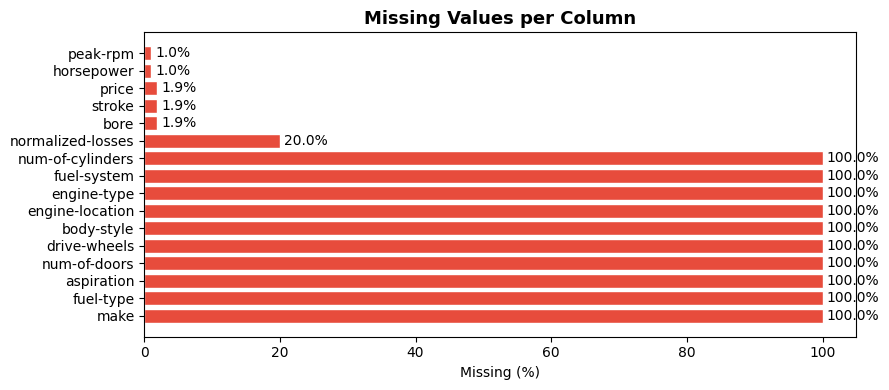

In [ ]:
missing     = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
missing_info = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(" Kolom dengan Missing Values ")
print(missing_info)

# Visualisasi
if not missing_info.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(missing_info.index, missing_info['Missing %'],
                   color='#e74c3c', edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values per Column', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

### 3.3 Distribusi Target: `price`

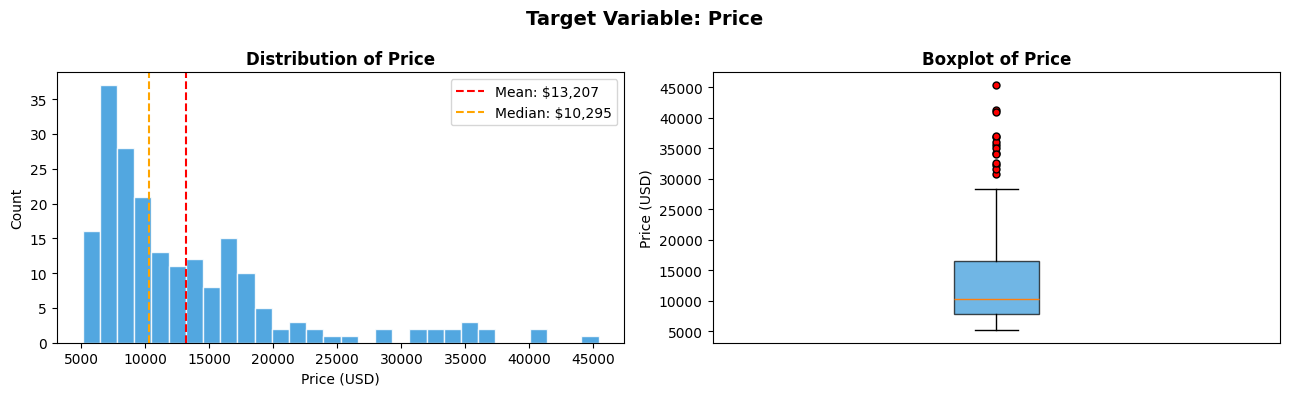

Skewness : 1.810  (right-skewed → log transform akan membantu)
Min      : $5,118
Max      : $45,400


In [ ]:
price_clean = df_eda['price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(price_clean, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(price_clean.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: ${price_clean.mean():,.0f}')
axes[0].axvline(price_clean.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${price_clean.median():,.0f}')
axes[0].set_title('Distribution of Price', fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
axes[1].boxplot(price_clean, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
axes[1].set_title('Boxplot of Price', fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xticks([])

plt.suptitle('Target Variable: Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness : {price_clean.skew():.3f}  (right-skewed → log transform akan membantu)")
print(f"Min      : ${price_clean.min():,.0f}")
print(f"Max      : ${price_clean.max():,.0f}")

### 3.4 Distribusi Fitur Numerik

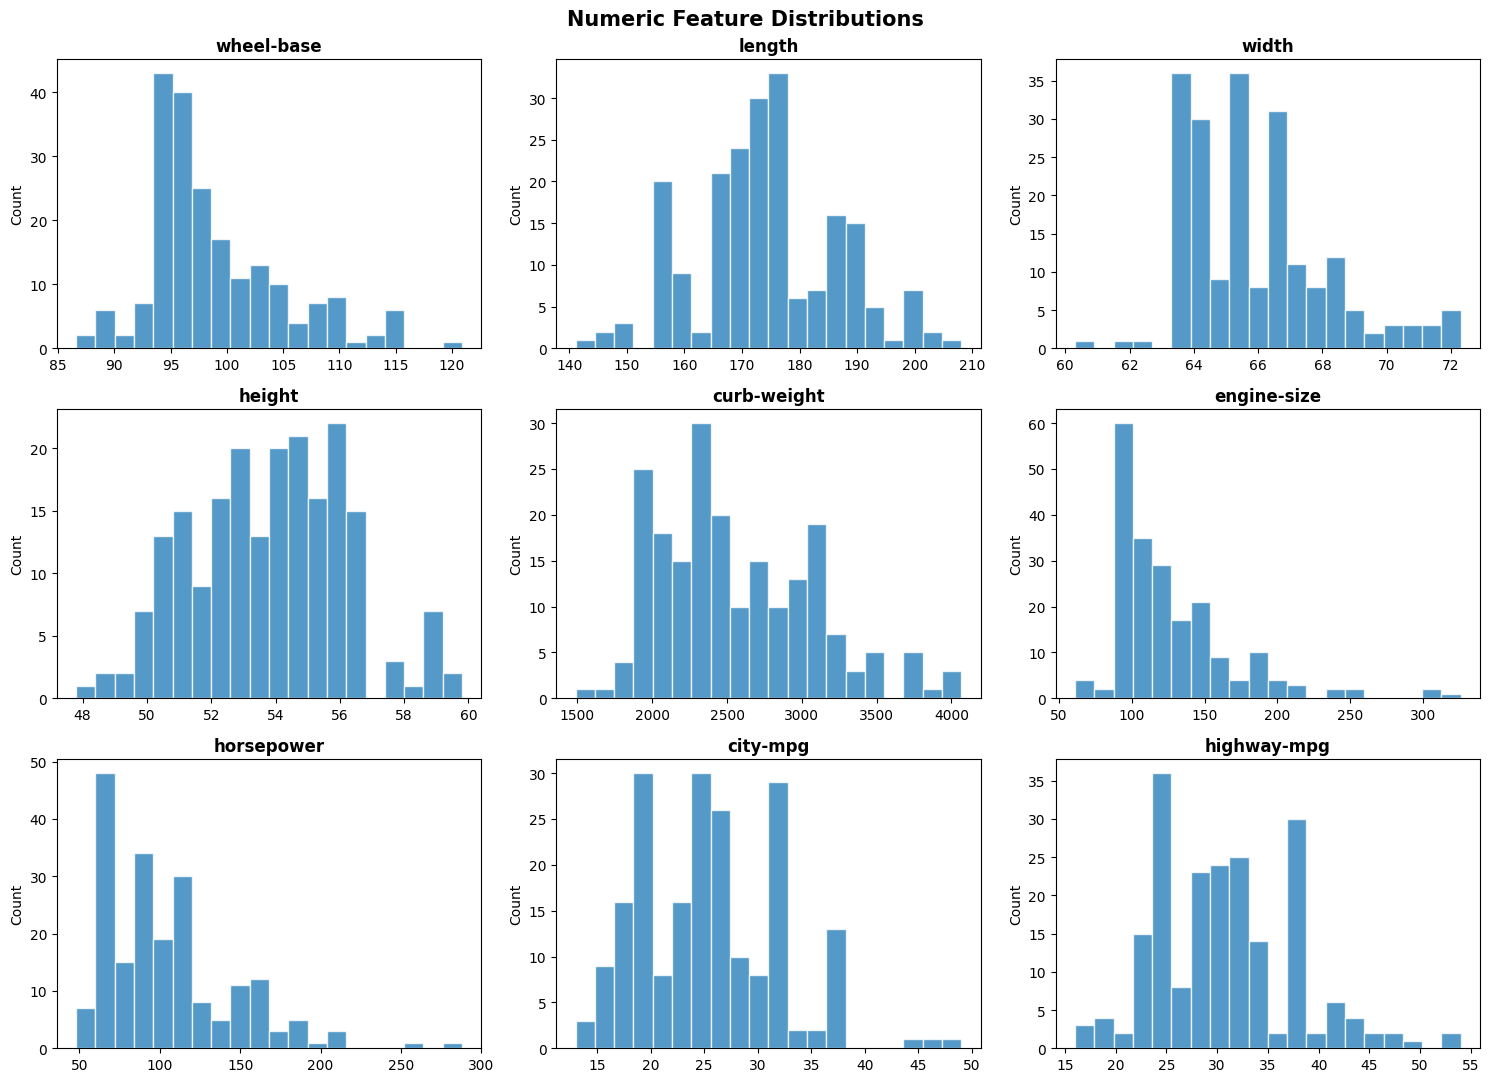

In [ ]:
num_feats = ['wheel-base', 'length', 'width', 'height',
             'curb-weight', 'engine-size', 'horsepower',
             'city-mpg', 'highway-mpg']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(num_feats):
    data = df_eda[feat].dropna()
    axes[i].hist(data, bins=20, color='#2980b9', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Analisis Korelasi dengan `price`

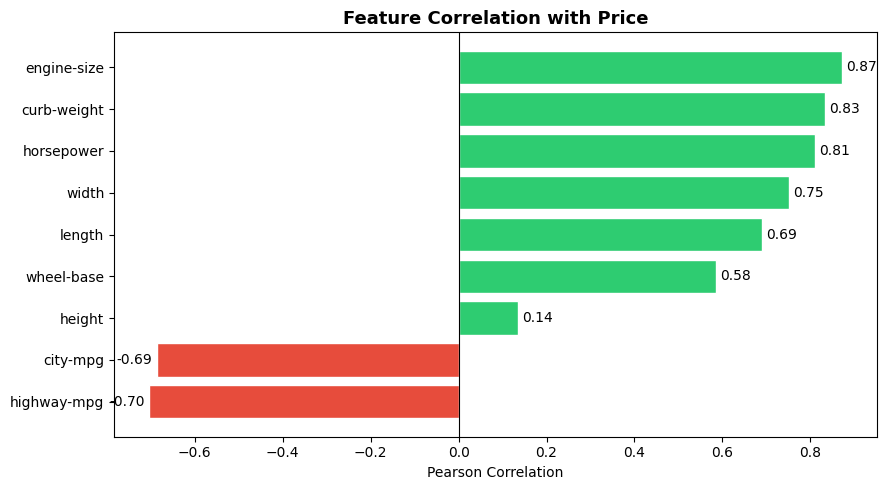

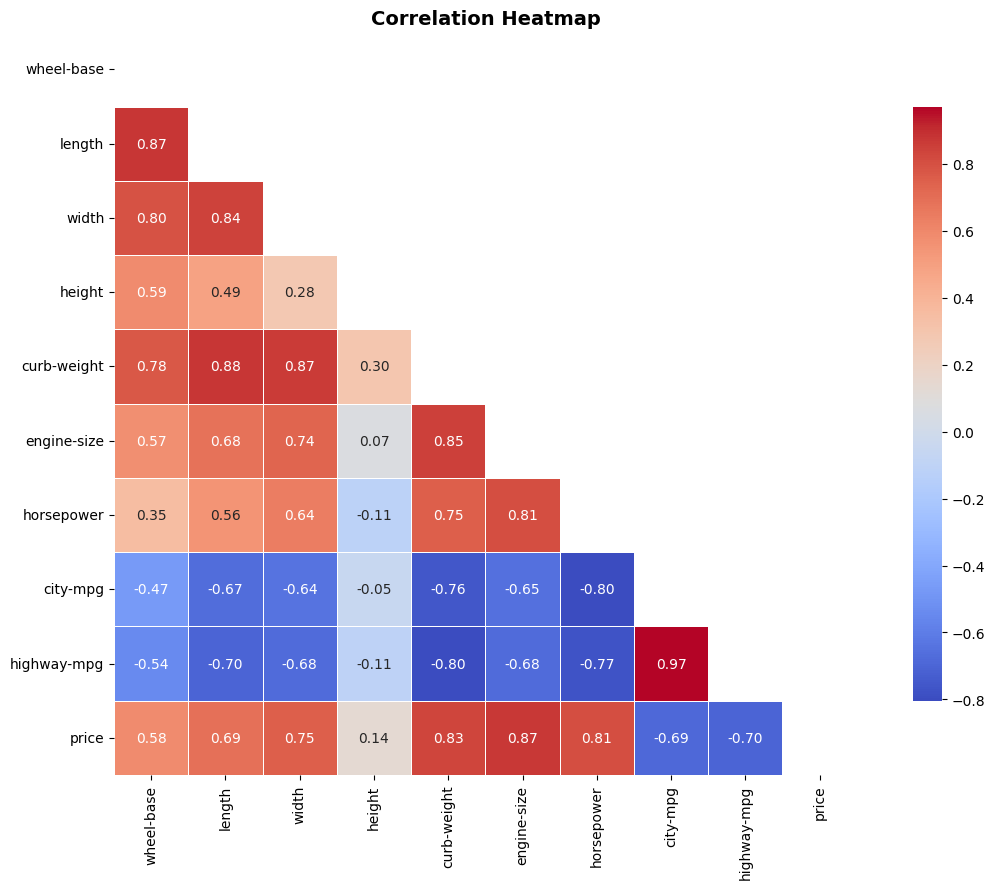

In [ ]:
corr_with_price = df_eda[num_feats + ['price']].corr()['price'].drop('price').sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_price]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_with_price.index, corr_with_price.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('Pearson Correlation')
ax.set_title('Feature Correlation with Price', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Full heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df_eda[num_feats + ['price']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

### 4.1 Cleaning & Handling Missing Values

In [ ]:
df_clean = df.copy()

# Ganti '?' dengan NaN
df_clean.replace('?', np.nan, inplace=True)

# Kolom numerik yang perlu dikonversi
numeric_cols = ['normalized-losses', 'bore', 'stroke',
                'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop row yang target-nya (price) kosong — tidak bisa dipakai untuk training
df_clean.dropna(subset=['price'], inplace=True)
print(f"Rows setelah drop target NaN : {len(df_clean)}")

# Imputasi fitur numerik dengan median
num_fill = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in num_fill:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Imputasi fitur kategorikal dengan modus
cat_fill = ['num-of-doors']
for col in cat_fill:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Missing values setelah imputasi:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f"\nFinal shape: {df_clean.shape}")

Rows setelah drop target NaN : 201
Missing values setelah imputasi:
Series([], dtype: int64)

Final shape: (201, 26)


### 4.2 Encoding Categorical Features

In [ ]:
cat_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal: {cat_columns}")

le = LabelEncoder()
df_encoded = df_clean.copy()

for col in cat_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("\nEncoding selesai.")
df_encoded.head()

Kolom kategorikal: ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']

Encoding selesai.


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,0,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,0,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,0,1,0,1,2,2,0,94.5,...,152,5,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,1,1,0,0,3,1,0,99.8,...,109,5,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,1,1,0,0,3,0,0,99.4,...,136,5,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 4.3 Log Transform Target

In [ ]:
USE_LOG_TARGET = True

if USE_LOG_TARGET:
    df_encoded['price_log'] = np.log1p(df_encoded['price'])
    target_col = 'price_log'
    print("Target: log1p(price)")
else:
    target_col = 'price'
    print("Target: price (raw)")

Target: log1p(price)


### 4.4 Feature Selection & Train/Test Split

In [ ]:
drop_cols = ['price', 'price_log'] if USE_LOG_TARGET else ['price']
X = df_encoded.drop(columns=drop_cols)
y = df_encoded[target_col]

# TTS 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Features   : {X.shape[1]}")
print(f"Train rows : {X_train.shape[0]}")
print(f"Test rows  : {X_test.shape[0]}")

Features   : 25
Train rows : 160
Test rows  : 41


### 4.5 Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"X_train_sc shape : {X_train_sc.shape}")
print(f"X_test_sc  shape : {X_test_sc.shape}")

StandardScaler applied.
X_train_sc shape : (160, 25)
X_test_sc  shape : (41, 25)


## 5. Evaluation Helper

In [ ]:
def evaluate_model(name, y_true_log, y_pred_log, use_log=USE_LOG_TARGET):
    """Hitung RMSE, MAE, MAPE, R² — kembalikan ke skala asli jika log transform."""
    if use_log:
        y_true = np.expm1(y_true_log)
        y_pred = np.expm1(y_pred_log)
    else:
        y_true = y_true_log
        y_pred = y_pred_log

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE  : ${rmse:>10,.2f}")
    print(f"  MAE   : ${mae:>10,.2f}")
    print(f"  MAPE  :  {mape:>9.2f}%")
    print(f"  R²    :  {r2:>9.4f}")

    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

## 6. Model Architecture Deeper ANN with Dropout

 Dropout untuk regularisasi, membantu mencegah overfitting.

In [ ]:
def build_model_B(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(1)  # output: regresi
    ], name='Deeper_ANN_Dropout')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

n_features = X_train_sc.shape[1]
model_B = build_model_B(n_features)
model_B.summary()

Model: "Deeper_ANN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,145 (55.25 KB)

 Non-trainable params: 448 (1.75 KB)

### 6.1 Training Model

In [ ]:
early_stop_B = EarlyStopping(monitor='val_loss', patience=25,
                             restore_best_weights=True, verbose=0)
reduce_lr_B  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=10, min_lr=1e-6, verbose=0)

history_B = model_B.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop_B, reduce_lr_B],
    verbose=2
)

best_epoch = np.argmin(history_B.history['val_loss']) + 1
best_val_loss = history_B.history['val_loss'][best_epoch - 1]
print(f"Epoch: {best_epoch}, Val Loss: {best_val_loss:.4f}")

Epoch 1/200
9/9 - 3s - 374ms/step - loss: 87.9788 - mae: 9.2846 - val_loss: 91.6979 - val_mae: 9.5586 - learning_rate: 0.0010
Epoch 2/200
9/9 - 0s - 15ms/step - loss: 85.9628 - mae: 9.2180 - val_loss: 88.0161 - val_mae: 9.3683 - learning_rate: 0.0010
Epoch 3/200
9/9 - 0s - 14ms/step - loss: 84.4237 - mae: 9.1517 - val_loss: 84.9425 - val_mae: 9.2028 - learning_rate: 0.0010
Epoch 4/200
9/9 - 0s - 15ms/step - loss: 83.0715 - mae: 9.0832 - val_loss: 82.4895 - val_mae: 9.0682 - learning_rate: 0.0010
Epoch 5/200
9/9 - 0s - 14ms/step - loss: 81.9213 - mae: 9.0101 - val_loss: 80.4352 - val_mae: 8.9548 - learning_rate: 0.0010
Epoch 6/200
9/9 - 0s - 14ms/step - loss: 80.3603 - mae: 8.9307 - val_loss: 78.4138 - val_mae: 8.8430 - learning_rate: 0.0010
Epoch 7/200
9/9 - 0s - 14ms/step - loss: 78.7729 - mae: 8.8437 - val_loss: 76.6667 - val_mae: 8.7430 - learning_rate: 0.0010
Epoch 8/200
9/9 - 0s - 14ms/step - loss: 77.0486 - mae: 8.7473 - val_loss: 74.7499 - val_mae: 8.6320 - learning_rate: 0.0010

## 7. Learning Curves

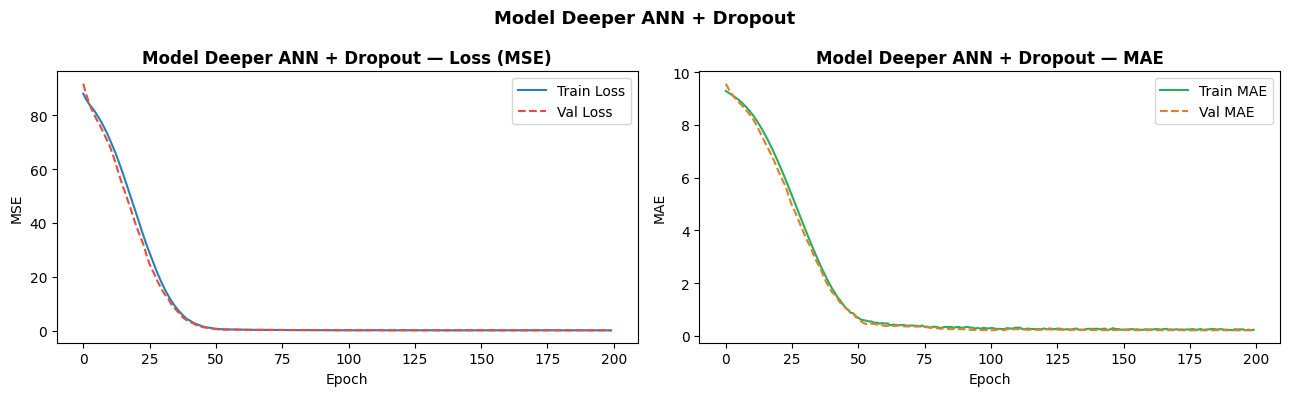

In [ ]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss', color='#2980b9')
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linestyle='--')
    axes[0].set_title(f'{title} — Loss (MSE)', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    # MAE
    axes[1].plot(history.history['mae'],     label='Train MAE', color='#27ae60')
    axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#e67e22', linestyle='--')
    axes[1].set_title(f'{title} — MAE', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_B, 'Model Deeper ANN + Dropout')

## 8. Evaluasi Model

### 8.1 Prediksi & Metrik

In [ ]:
y_pred = model_B.predict(X_test_sc, verbose=0).flatten()

results = evaluate_model('Model Deeper ANN + Dropout', y_test, y_pred)


  Model Deeper ANN + Dropout
  RMSE  : $  6,366.97
  MAE   : $  3,968.82
  MAPE  :      19.96%
  R²    :     0.6687
